# Stance Detection: Opini Publik Indonesia Terhadap Kasus Kekerasan Seksual
**Dataset:** finalDataUNY.csv  
**Models:** BiLSTM + Embedding | BiLSTM + Embedding + Attention  
**Target:** stance (Neutral, Advocacy, Supportive, VictimBlaming)

## 1. SETUP  & PREPARATION DATA

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 4.5 MB/s eta 0:00:00


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense,
    Dropout, GlobalMaxPooling1D, Layer
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K

print('Set Up Selesai')
np.random.seed(42)

Set Up Selesai


## 2. LOAD DATA


In [4]:
path = "/content/drive/MyDrive/Gemastik/DataFinal/finalDataUNY.csv"
data = pd.read_csv(path)
print('jumlah Baris dan Kolom pada data: ', data.shape)
data.head()

jumlah Baris dan Kolom pada data:  (1500, 2)


,text,stance
0,udh bener di UGM aja lah,Neutral
1,jurusan hukum ❎\npraktek hukum ✅,Neutral
2,"Ini masalah rusaknya moral, bukan hal yang sep...",Advocacy
3,DO aja semuanya,Advocacy
4,Usut tuntas proses hukum dan pecat mahasiswa b...,Advocacy


## 3. EDA (EXPLORATORY DATA ANALYSIS)

In [5]:
print('Info Dataset:')
data.info()
print()
print('Missing Values:')
print(data.isnull().sum())
print()
print('Duplicates Values:')
print(data.duplicated().sum())
print()
print('Distribusi Opini Publik:')
print(data['stance'].value_counts())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1500 non-null   object
 1   stance  1500 non-null   object
dtypes: object(2)
memory usage: 23.6+ KB

Missing Values:
text      0
stance    0
dtype: int64

Duplicates Values:
0

Distribusi Opini Publik:
stance
Neutral          1108
Advocacy          210
Supportive        129
VictimBlaming      53
Name: count, dtype: int64


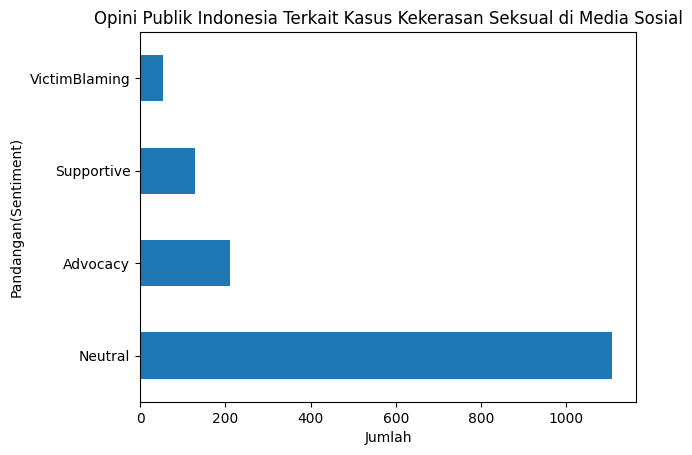

Jumlah Opini Publik Terhadap Kasus Kekerasan Seksual di Media Sosial stance
Neutral          1108
Advocacy          210
Supportive        129
VictimBlaming      53
Name: count, dtype: int64


In [6]:
hitungText = data['stance'].value_counts()

plt.figure()
hitungText.plot(kind = 'barh')
plt.title("Opini Publik Indonesia Terkait Kasus Kekerasan Seksual di Media Sosial")
plt.xlabel("Jumlah")
plt.ylabel("Pandangan(Sentiment)")
plt.show()

print("Jumlah Opini Publik Terhadap Kasus Kekerasan Seksual di Media Sosial",
      hitungText)

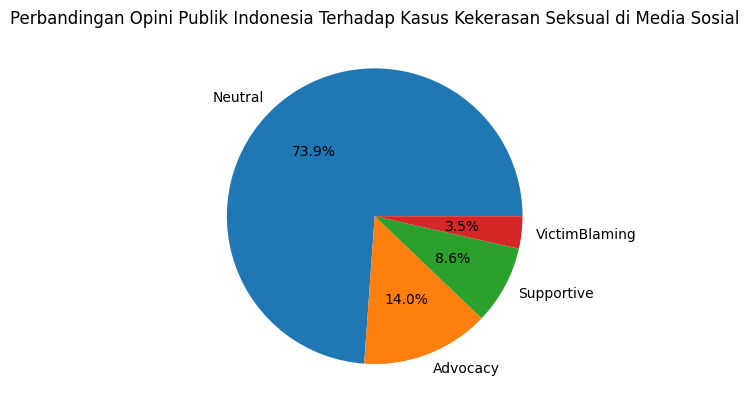

In [7]:
plt.figure()
hitungText.plot(kind='pie', autopct = '%1.1f%%')
plt.title("Perbandingan Opini Publik Indonesia Terhadap Kasus Kekerasan Seksual di Media Sosial")
plt.ylabel('')
plt.show()

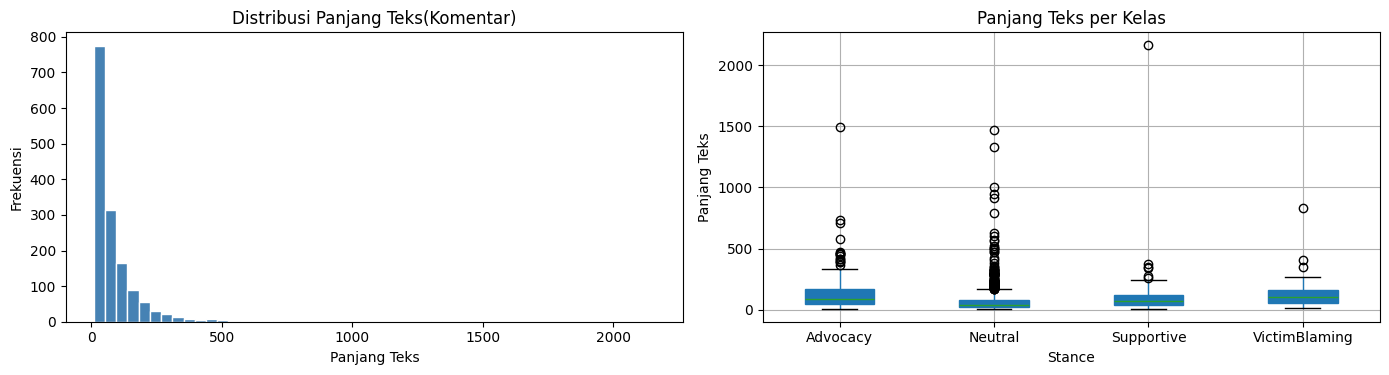

count    1500.000000
mean       88.553333
std       128.391425
min        10.000000
25%        28.000000
50%        51.000000
75%       103.000000
max      2160.000000
Name: panjangData, dtype: float64


In [8]:
data['panjangData'] = data['text'].apply(len)

fig,axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['panjangData'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Teks(Komentar)', fontsize=12)
axes[0].set_xlabel('Panjang Teks')
axes[0].set_ylabel('Frekuensi')

data.boxplot(column='panjangData',by='stance',ax=axes[1],patch_artist=True)
axes[1].set_title('Panjang Teks per Kelas',fontsize=12)
axes[1].set_xlabel('Stance')
axes[1].set_ylabel('Panjang Teks')
plt.suptitle('')

plt.tight_layout()
plt.show()
print(data['panjangData'].describe())

## 4. DATA CLEANING

In [9]:
slangIndonesia = [
    (r'\bkalo ga\b','kalau tidak'),(r'\bkalo gak\b','kalau tidak'),
    (r'\bgabisa\b','tidak bisa'),(r'\bgatau\b','tidak tahu'),
    (r'\bgtau\b','tidak tahu'),(r'\bgada\b','tidak ada'),
    (r'\bgaada\b','tidak ada'),(r'\bgakuat\b','tidak kuat'),
    (r'\bkaga\b','tidak'),(r'\bngga\b','tidak'),(r'\bnggak\b','tidak'),
    (r'\bnggk\b','tidak'),(r'\bgak\b','tidak'),(r'\bgk\b','tidak'),
    (r'\bga\b','tidak'),(r'\bkgk\b','tidak'),(r'\bnga\b','tidak'),
    (r'\bbngt\b','banget'),(r'\bbngeet\b','banget'),(r'\bbangeett\b','banget'),
    (r'\bbangettt\b','banget'),(r'\bbangett\b','banget'),
    (r'\bbgtt\b','banget'),(r'\bbgt\b','banget'),
    (r'\bampek\b','sampai'),(r'\bsampe\b','sampai'),(r'\bsmpe\b','sampai'),
    (r'\bampe\b','sampai'),(r'\bskrng\b','sekarang'),(r'\bskrg\b','sekarang'),
    (r'\bsudh\b','sudah'),(r'\budah\b','sudah'),(r'\budh\b','sudah'),
    (r'\buda\b','sudah'),(r'\bsdh\b','sudah'),(r'\btrss\b','terus'),
    (r'\btrs\b','terus'),(r'\bdpet\b','dapat'),(r'\bdapet\b','dapat'),
    (r'\bdpt\b','dapat'),(r'\bblum\b','belum'),(r'\bblm\b','belum'),
    (r'\bpakek\b','pakai'),(r'\bpake\b','pakai'),(r'\bpke\b','pakai'),
    (r'\bFakyltas\b','fakultas'),(r'\bkrena\b','karena'),(r'\bkrna\b','karena'),
    (r'\bkarna\b','karena'),(r'\bkrn\b','karena'),(r'\bkayak\b','seperti'),
    (r'\bkaya\b','seperti'),(r'\bkyk\b','seperti'),(r'\bkek\b','seperti'),
    (r'\bkalo\b','kalau'),(r'\bklo\b','kalau'),(r'\bklu\b','kalau'),
    (r'\bkl\b','kalau'),(r'\btapii\b','tapi'),(r'\btpi\b','tapi'),
    (r'\btp\b','tapi'),(r'\bjugaa\b','juga'),(r'\bjga\b','juga'),
    (r'\bjg\b','juga'),(r'\byng\b','yang'),(r'\byg\b','yang'),
    (r'\bdgn\b','dengan'),(r'\bdrpd\b','daripada'),(r'\bdr\b','dari'),
    (r'\bmsih\b','masih'),(r'\bmsh\b','masih'),(r'\bmnurut\b','menurut'),
    (r'\bmnrt\b','menurut'),(r'\bmrk\b','mereka'),(r'\bbnyk\b','banyak'),
    (r'\bbyk\b','banyak'),(r'\bgmna\b','bagaimana'),(r'\bgimana\b','bagaimana'),
    (r'\bgmn\b','bagaimana'),(r'\bknapa\b','kenapa'),(r'\bknp\b','kenapa'),
    (r'\bpdhal\b','padahal'),(r'\bpdhl\b','padahal'),(r'\bspt\b','seperti'),
    (r'\bsm\b','sama'),(r'\baj\b','saja'),(r'\byuk\b','ayo'),
    (r'\bantemono\b','pukul'),(r'\bsj\b','saja'),(r'\bmna\b','mana'),
    (r'\bmn\b','mana'),(r'\bmnghukum\b','menghukum'),(r'\bkluarin\b','keluarkan'),
    (r'\bbkn\b','bukan'),(r'\bank\b','anak'),(r'\bemane\b','sayang'),
    (r'\bthx\b','terima kasih'),(r'\butk\b','untuk'),(r'\btruz\b','terus'),
    (r'\bfhui\b','fakultas hukum universitas indonesia'),
    (r'\bfh ui\b','fakultas hukum universitas indonesia'),
    (r'\bfh\b','fakultas hukum'),(r'\bui\b','universitas indonesia'),
    (r'\bks\b','kekerasan seksual'),(r'\bdo\b','drop out'),
    (r'\bppks\b','satgas kekerasan seksual'),(r'\bptn\b','perguruan tinggi negeri'),
    (r'\bpubspeak\b','public speaking'),
    (r'\bplisss\b',''),(r'\bpliss\b',''),(r'\bplis\b',''),(r'\bpls\b',''),
    (r'\banjirr\b',''),(r'\banjir\b',''),(r'\bnjirr\b',''),(r'\bnjir\b',''),
    (r'\banjg\b',''),(r'\banj\b',''),(r'\bjirr\b',''),(r'\bjir\b',''),
    (r'\bwkwkwkwk\b',''),(r'\bwkwkwk\b',''),(r'\bwkwk\b',''),
    (r'\bhahahaha\b',''),(r'\bhahaha\b',''),(r'\bhaha\b',''),
    (r'\bhehe\b',''),(r'\bhihi\b',''),(r'\blmao\b',''),(r'\blol\b',''),
    (r'\bwtf\b',''),(r'\bomg\b',''),(r'\bwth\b',''),
    (r'\bcok\b',''),(r'\bcuy\b',''),(r'\bwoy\b',''),(r'\bwoi\b',''),
    (r'\bih\b',''),(r'\bcih\b',''),(r'\bbtw\b',''),(r'\bfyi\b',''),
    (r'\bcmiiw\b',''),(r'\bcmww\b',''),(r'\bokk\b',''),(r'\boke\b',''),
    (r'\bsih\b',''),(r'\bnih\b',''),(r'\bdong\b',''),
    (r'\bdeh\b',''),(r'\bkok\b',''),(r'\bkan\b',''),
    (r'\blah\b',''),(r'\byah\b',''),(r'\byaa\b',''),
    (r'\bnah\b',''),(r'\beh\b',''),(r'\bahh\b',''),
    (r'\buhh\b',''),(r'\bah\b',''),
]

factory = StopWordRemoverFactory()
sastrawi = set(factory.get_stop_words())

kataDomain = {
    'korban','pelaku','pelecehan','kekerasan','seksual',
    'perempuan','wanita','cewe','cewek',
    'hukum','kampus','universitas','dosen','mahasiswa','mahasiswi',
    'keadilan','trauma','consent','verbal',
    'grup','chat','speak','drop','out',
    'moral','adab','etika',
    'tidak','bukan','belum','jangan','tanpa',
    'sedih','marah','kecewa','malu','miris','sakit','hancur',
    'berani','salut','bangga','keren','hebat','solid',
    'semangat','dukung','bela','lindungi','aman',
    'proses','sanksi','hukuman','sidang','investigasi',
    'kasus','inside','joke','jokes','template','objektifikasi',
    'normalisasi','penegak',
    'tidak','bisa','mau','tahu','ada',
}

kataTambahan = {
    'kak','bang','nih','sih','dong','deh','aja',
    'udah','ga','gak','nggak','aku','gue','gua','gw',
    'lu','lo','elu','elo','kamu','dia','mereka','kita','kami',
    'itu','ini','jadi','kan','lah','kok',
    'ya','yaa','yah','eh','ah','oh',
    'sticker','fyp','tiktok','like','follow','share',
}

stopWords = (sastrawi.union(kataTambahan)) - kataDomain

def normalisasiSlang(text):
    for x, y in slangIndonesia:
        text = re.sub(x, y, text, flags=re.IGNORECASE)
    return text

def cleanText(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = normalisasiSlang(text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def hapusStopWords(text):
    words = text.split()
    filtered = [w for w in words if w.lower() not in stopWords or w.lower() in kataDomain]
    return ' '.join(filtered)

def final(text):
    clean = cleanText(text)
    rmv   = hapusStopWords(clean)
    return ' '.join([w for w in rmv.split() if len(w) > 1])

In [10]:
data['CleanText'] = data['text'].apply(final)
data = data[data['CleanText'].str.strip() != ''].reset_index(drop=True)

data.head()

,text,stance,panjangData,CleanText
0,udh bener di UGM aja lah,Neutral,24,bener ugm
1,jurusan hukum ❎\npraktek hukum ✅,Neutral,31,jurusan hukum praktek hukum
2,"Ini masalah rusaknya moral, bukan hal yang sep...",Advocacy,179,rusaknya moral bukan sepele emoji tertawa diku...
3,DO aja semuanya,Advocacy,15,drop out
4,Usut tuntas proses hukum dan pecat mahasiswa b...,Advocacy,50,usut tuntas proses hukum pecat mahasiswa bejat


## 5. ENCODING LABELS

In [11]:
label = {
    'Supportive' : 0,
    'VictimBlaming' : 1,
    'Neutral': 2,
    'Advocacy': 3

}

data['label'] = data['stance'].map(label)
data['label'].value_counts()

,count
label,
2,1098
3,210
0,129
1,53


## 6. TRAIN AND VALIDATION

In [12]:
X = data['CleanText'].values
y = data['label'].values

TrainX, ValX, TrainY, ValY = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(TrainX), len(ValX)

(1192, 298)

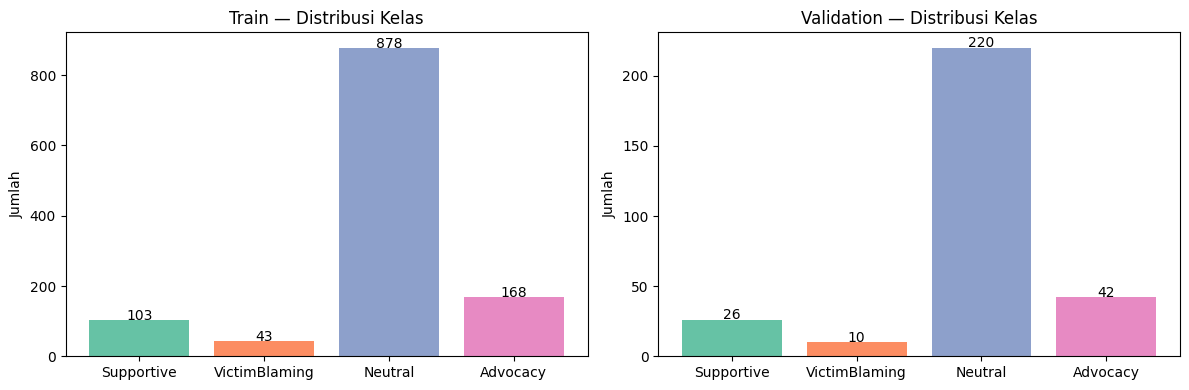

In [13]:
namaLabel = {
    0: 'Supportive',
    1: 'VictimBlaming',
    2: 'Neutral',
    3: 'Advocacy'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
jumlahTrain = pd.Series(TrainY).value_counts().sort_index()

axes[0].bar(
    [namaLabel[i] for i in jumlahTrain.index],
    jumlahTrain.values,
    color=sns.color_palette('Set2', 4)
)

axes[0].set_title('Train — Distribusi Kelas')
axes[0].set_ylabel('Jumlah')

for indeks, nilai in enumerate(jumlahTrain.values):
    axes[0].text(indeks, nilai + 0.5, str(nilai), ha='center')

jumlahValidasi = pd.Series(ValY).value_counts().sort_index()

axes[1].bar(
    [namaLabel[i] for i in jumlahValidasi.index],
    jumlahValidasi.values,
    color=sns.color_palette('Set2', 4)
)

axes[1].set_title('Validation — Distribusi Kelas')
axes[1].set_ylabel('Jumlah')

for indeks, nilai in enumerate(jumlahValidasi.values):
    axes[1].text(indeks, nilai + 0.5, str(nilai), ha='center')

plt.tight_layout()
plt.show()

## 7. FEATURE ENGINEERING

In [14]:
VOCAB_SIZE   = 10_000
MAX_LEN      = 100
EMBED_DIM    = 128
LSTM_UNITS   = 64
DROPOUT_RATE = 0.4
BATCH_SIZE   = 32
EPOCHS       = 30
NUM_CLASSES  = 4

label_names = ['Supportive', 'VictimBlaming', 'Neutral', 'Advocacy']
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(TrainX)

print(f'vocab total: {len(tokenizer.word_index)}')
print(f'pake top {VOCAB_SIZE}')

TrainSeq = pad_sequences(tokenizer.texts_to_sequences(TrainX),
                         maxlen=MAX_LEN, padding='post', truncating='post')
ValSeq   = pad_sequences(tokenizer.texts_to_sequences(ValX),
                         maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\ntrain shape: {TrainSeq.shape}')
print(f'val shape  : {ValSeq.shape}')

TrainY_cat = to_categorical(TrainY, num_classes=NUM_CLASSES)
ValY_cat   = to_categorical(ValY,   num_classes=NUM_CLASSES)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(TrainY),
    y=TrainY
)

class_weights = {}
for i in range(len(class_weights_arr)):
    class_weights[i] = class_weights_arr[i]

print('\nBobot Kelas:')
for idx, w in class_weights.items():
    print(f'{label_names[idx]:15s} = {w:.4f}')

vocab total: 3370
pake top 10000

train shape: (1192, 100)
val shape  : (298, 100)

Bobot Kelas:
Supportive      = 2.8932
VictimBlaming   = 6.9302
Neutral         = 0.3394
Advocacy        = 1.7738


## 8. MODELLING

### Model 1 — BiLSTM + Embedding

In [15]:
def build_bilstm(vocab_size, embed_dim, max_len, lstm_units,dropout_rate, num_classes):
    inp = Input(shape=(max_len,), name='input')
    x = Embedding(vocab_size, embed_dim, name='embedding')(inp)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True), name='bilstm')(x)
    x = GlobalMaxPooling1D(name='global_max_pool')(x)
    x = Dropout(dropout_rate, name='dropout')(x)
    x = Dense(64, activation='relu', name='dense')(x)
    out = Dense(num_classes, activation='softmax', name='output')(x)
    model = Model(inputs=inp, outputs=out, name='BiLSTM_Embedding')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model1 = build_bilstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN,
                      LSTM_UNITS, DROPOUT_RATE, NUM_CLASSES)
model1.summary()

Model: "BiLSTM_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,332 (5.29 MB)

 Trainable params: 1,387,332 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 — BiLSTM + Embedding + Attention

In [16]:
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(
            name='att_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(
            name='att_bias',
            shape=(input_shape[-1],),
            initializer='zeros', trainable=True)
        self.u = self.add_weight(
            name='att_context',
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform', trainable=True)

        super().build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        e = K.dot(e, self.u)
        alpha = K.softmax(e, axis=1)
        context = K.sum(x * alpha, axis=1)
        return context
    def get_config(self):
        return super().get_config()


def build_bilstm_attention(vocab_size, embed_dim, max_len, lstm_units,dropout_rate,num_classes):
    inp = Input(shape=(max_len,), name='input')
    x = Embedding(vocab_size, embed_dim, name='embedding')(inp)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True), name='bilstm')(x)
    x = AttentionLayer(name='attention')(x)
    x = Dropout(dropout_rate, name='dropout')(x)
    x = Dense(64, activation='relu', name='dense')(x)
    out = Dense(num_classes, activation='softmax', name='output')(x)
    model = Model(inputs=inp, outputs=out, name='BiLSTM_Embedding_Attention')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
model2 = build_bilstm_attention(VOCAB_SIZE, EMBED_DIM, MAX_LEN,
                                LSTM_UNITS, DROPOUT_RATE, NUM_CLASSES)
model2.summary()

Model: "BiLSTM_Embedding_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,403,972 (5.36 MB)

 Trainable params: 1,403,972 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

## 9. TRAINING

### TRAINING MODEL 1 BiLSTM + Embedding

In [17]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]
print('=' * 50)
print('Training Model 1 — BiLSTM + Embedding')
print('=' * 50)
history1 = model1.fit(
    TrainSeq, TrainY_cat,
    validation_data=(ValSeq, ValY_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Training Model 1 — BiLSTM + Embedding
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.2483 - loss: 1.3875 - val_accuracy: 0.7315 - val_loss: 1.3361 - learning_rate: 0.0010
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.3926 - loss: 1.3570 - val_accuracy: 0.3188 - val_loss: 1.3713 - learning_rate: 0.0010
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.5285 - loss: 1.1976 - val_accuracy: 0.4966 - val_loss: 1.3223 - learning_rate: 0.0010
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.6477 - loss: 0.8429 - val_accuracy: 0.5503 - val_loss: 1.1701 - learning_rate: 0.0010
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.8356 - loss: 0.4252 - val_accuracy: 0.6980 - val_loss: 1.0462 - learning_rate: 0.0010
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.9262 - loss: 0.1858 - val_accuracy: 0.6980 - val_loss: 0.9422 - learning_rate: 0.0010
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/

### TRAINING MODEL 2 BiLSTM + Embedding + Attention

In [18]:
print('=' * 50)
print('Training Model 2 — BiLSTM + Embedding + Attention')
print('=' * 50)
history2 = model2.fit(
    TrainSeq, TrainY_cat,
    validation_data=(ValSeq, ValY_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Training Model 2 — BiLSTM + Embedding + Attention
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 241ms/step - accuracy: 0.2592 - loss: 1.3920 - val_accuracy: 0.1074 - val_loss: 1.3441 - learning_rate: 0.0010
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.4010 - loss: 1.3566 - val_accuracy: 0.6779 - val_loss: 1.2231 - learning_rate: 0.0010
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7385 - loss: 1.2340
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.7156 - loss: 1.1697 - val_accuracy: 0.6644 - val_loss: 1.0941 - learning_rate: 0.0010
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - accuracy: 0.7349 - loss: 0.8839 - val_accuracy: 0.1644 - val_loss: 1.2212 - learning_rate: 5.0000e-04
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.5168 - loss: 0.6635 - val_accuracy: 0.1678 - val_loss: 1.5364 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Rest

## 10. TRAINING CURVES

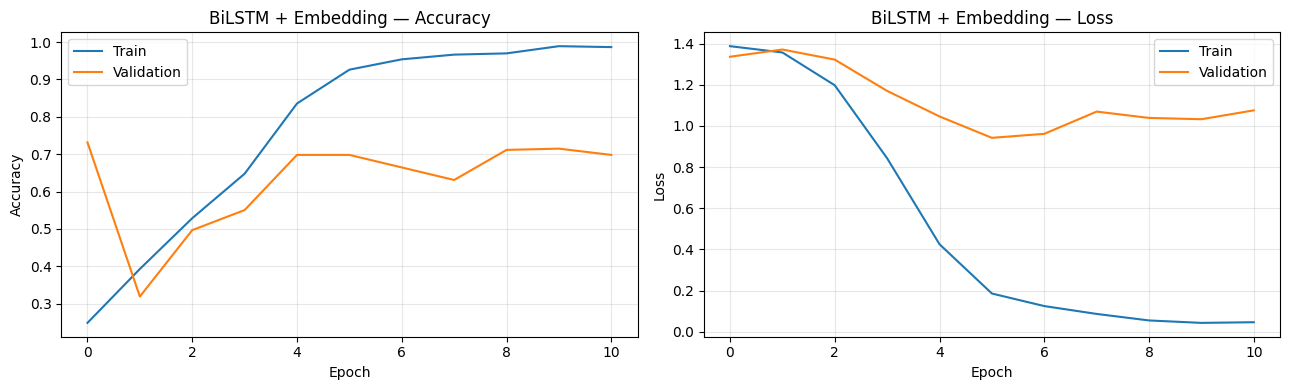

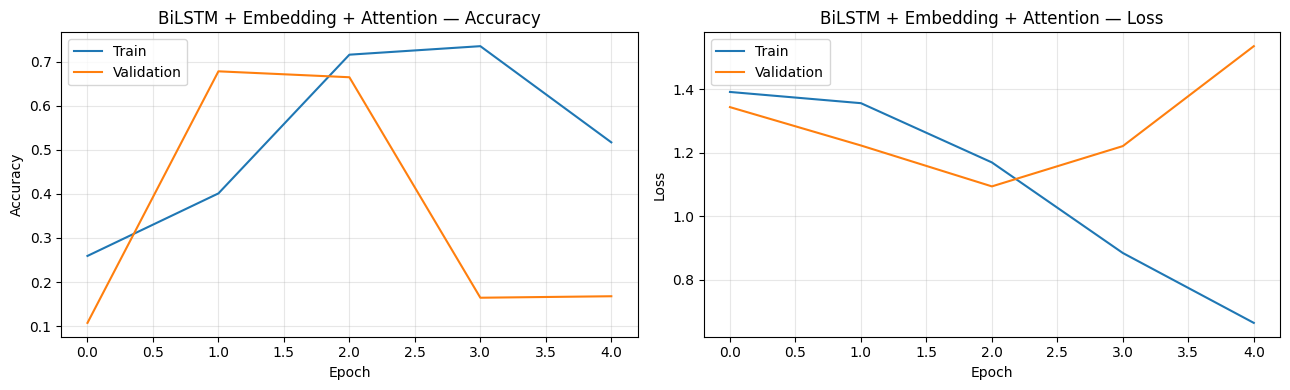

In [19]:
def LearningCurve(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

LearningCurve(history1,'BiLSTM + Embedding')
LearningCurve(history2,'BiLSTM + Embedding + Attention')

## 11. EVALUATION


  Evaluation — BiLSTM + Embedding

Classification Report:
               precision    recall  f1-score   support

   Supportive     0.4167    0.3846    0.4000        26
VictimBlaming     0.2778    0.5000    0.3571        10
      Neutral     0.8791    0.7273    0.7960       220
     Advocacy     0.4459    0.7857    0.5690        42

     accuracy                         0.6980       298
    macro avg     0.5049    0.5994    0.5305       298
 weighted avg     0.7575    0.6980    0.7147       298



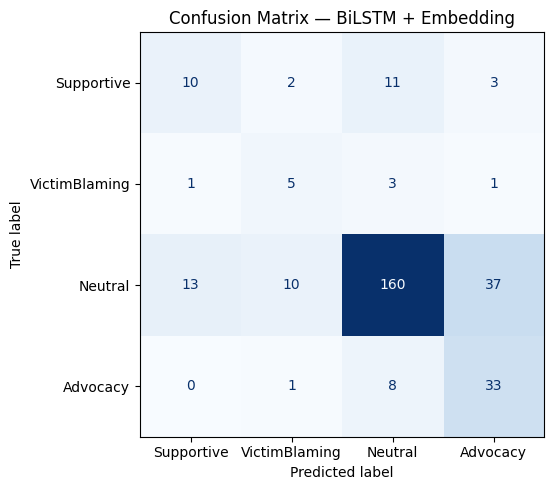


  Evaluation — BiLSTM + Embedding + Attention

Classification Report:
               precision    recall  f1-score   support

   Supportive     0.0915    1.0000    0.1677        26
VictimBlaming     0.0000    0.0000    0.0000        10
      Neutral     0.0000    0.0000    0.0000       220
     Advocacy     0.4286    0.1429    0.2143        42

     accuracy                         0.1074       298
    macro avg     0.1300    0.2857    0.0955       298
 weighted avg     0.0684    0.1074    0.0448       298



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


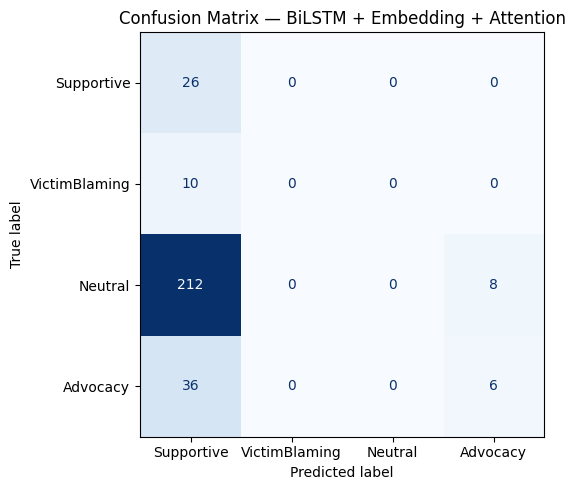

In [20]:
def evaluate_model(model, ValSeq, ValY, label_names, model_name):
    print(f'\n{"=" * 55}')
    print(f'  Evaluation — {model_name}')
    print(f'{"=" * 55}')

    pred_probs = model.predict(ValSeq, verbose=0)
    pred_labels = np.argmax(pred_probs, axis=1)

    print('\nClassification Report:')
    print(classification_report(ValY, pred_labels,
                                 target_names=label_names, digits=4))
    cm = confusion_matrix(ValY, pred_labels)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12)
    plt.tight_layout()
    plt.show()

    return pred_labels

pred1 = evaluate_model(model1, ValSeq, ValY, label_names, 'BiLSTM + Embedding')
pred2 = evaluate_model(model2, ValSeq, ValY, label_names, 'BiLSTM + Embedding + Attention')

##12. MODEL COMPARISION

                         Model  Val Accuracy  Macro F1  Weighted F1
            BiLSTM + Embedding      0.697987  0.530532     0.714739
BiLSTM + Embedding + Attention      0.107383  0.095507     0.044837


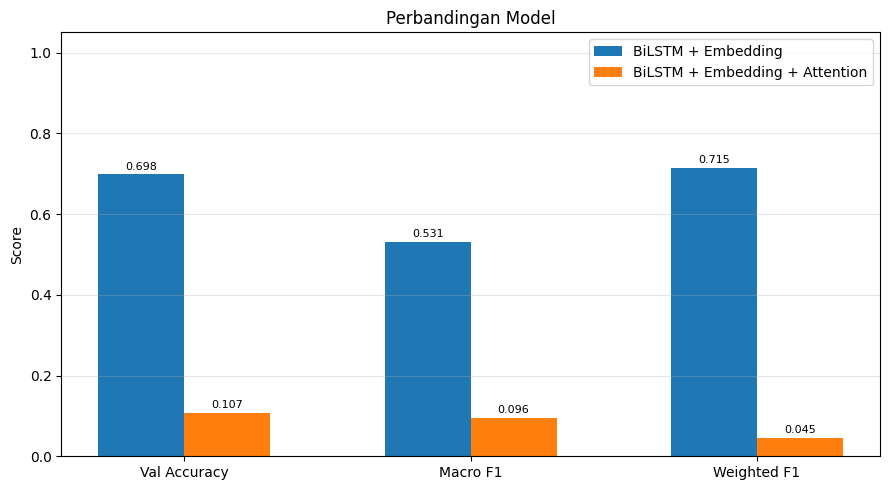

In [21]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Model': [
        'BiLSTM + Embedding',
        'BiLSTM + Embedding + Attention',
    ],
    'Val Accuracy': [
        accuracy_score(ValY, pred1),
        accuracy_score(ValY, pred2),
    ],
    'Macro F1': [
        f1_score(ValY, pred1, average='macro'),
        f1_score(ValY, pred2, average='macro'),
    ],
    'Weighted F1': [
        f1_score(ValY, pred1, average='weighted'),
        f1_score(ValY, pred2, average='weighted'),
    ],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

metrics = ['Val Accuracy', 'Macro F1', 'Weighted F1']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
for i, (_, row) in enumerate(df_results.iterrows()):
    ax.bar(x + i * width,
           [row['Val Accuracy'], row['Macro F1'], row['Weighted F1']],
           width=width, label=row['Model'])

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Perbandingan Model')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()